In [1]:
import os
import sys
import math
import warnings
import contextlib
import io
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


In [2]:
available_evolution_models = []

for name in dir(evolution):
    obj = getattr(evolution, name)

    if inspect.isclass(obj):
        available_evolution_models.append(name)

print("Available evolution-model classes:")
for name in sorted(available_evolution_models):
    print(name)

Available evolution-model classes:
Baraffe15
Column
Ekstrom12
Geneva
Isochrone
MISTv1
MergedBaraffePisaEkstromParsec
MergedPisaEkstromParsec
MergedSiessGenevaPadova
Parsec
Pisa
StellarEvolution
Table


In [3]:
import math
from pathlib import Path

import numpy as np
from astropy.table import Table, Column


UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/'
)


class MergedBaraffePisaEkstromParsecDAT:
    """
    Compatibility reader for SPISEA's merged evolution grid stored as
    ASCII .dat files.

    This class has the interface required by SPISEA's IsochronePhot:
        - age_list
        - z_list
        - z_solar
        - isochrone(age, metallicity)

    Parameters
    ----------
    root_dir : str or Path
        Directory containing z015_rot/ and z015_norot/.

    rot : bool
        Read the rotating or non-rotating merged grid.
    """

    def __init__(self, root_dir, rot=True):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)

        self.model_dir = self.root_dir
        self.z_list = [0.015]
        self.z_solar = 0.015

        self.grid_dir = self.root_dir / (
            'z015_rot' if self.rot else 'z015_norot'
        )

        if not self.grid_dir.is_dir():
            raise FileNotFoundError(
                f"Merged-model directory not found: {self.grid_dir}"
            )

        # Determine ages from the files that really exist rather than
        # assuming a perfectly complete numerical sequence.
        paths = sorted(self.grid_dir.glob('iso_*.dat'))

        if len(paths) == 0:
            raise FileNotFoundError(
                f"No iso_*.dat files found in {self.grid_dir}"
            )

        self.age_file_map = {}

        for path in paths:
            try:
                log_age = float(path.stem.split('_')[1])
            except (IndexError, ValueError):
                continue

            self.age_file_map[round(log_age, 2)] = path

        self.age_list = np.array(
            sorted(self.age_file_map.keys()),
            dtype=float
        )

        # Not used by your analysis directly, but retained for compatibility.
        self.mass_list = []

    def isochrone(self, age=1.0e6, metallicity=0.0):
        """
        Return the nearest available merged isochrone at or above the
        requested age, following the behavior of the older SPISEA readers.
        """
        log_age_requested = math.log10(age)

        if log_age_requested < self.age_list[0]:
            raise ValueError(
                f"Requested logAge={log_age_requested:.4f} is younger than "
                f"the merged grid minimum logAge={self.age_list[0]:.2f}."
            )

        if log_age_requested > self.age_list[-1]:
            raise ValueError(
                f"Requested logAge={log_age_requested:.4f} is older than "
                f"the merged grid maximum logAge={self.age_list[-1]:.2f}."
            )

        # Use nearest grid age rather than floating-point equality.
        age_idx = np.argmin(
            np.abs(self.age_list - log_age_requested)
        )
        selected_log_age = float(self.age_list[age_idx])
        iso_path = self.age_file_map[
            round(selected_log_age, 2)
        ]

        iso = Table.read(
            iso_path,
            format='ascii',
            comment='#',
            names=[
                'mass',
                'logT',
                'logL',
                'logg',
                'logT_WR',
                'mass_current',
                'phase',
                'model_ref',
            ],
        )

        # Ensure numeric columns have predictable types.
        for colname in [
            'mass',
            'logT',
            'logL',
            'logg',
            'logT_WR',
            'mass_current',
        ]:
            iso[colname] = np.asarray(
                iso[colname],
                dtype=float
            )

        iso['phase'] = np.asarray(
            iso['phase'],
            dtype=int
        )

        # SPISEA expects an isWR flag.
        is_wr = np.asarray(
            ~np.isclose(
                iso['logT'],
                iso['logT_WR'],
                rtol=0.0,
                atol=1e-8,
            ),
            dtype=bool,
        )

        iso.add_column(
            Column(is_wr, name='isWR')
        )

        iso.meta['log_age'] = selected_log_age
        iso.meta['log_age_requested'] = log_age_requested
        iso.meta['metallicity_in'] = metallicity
        iso.meta['metallicity_act'] = 0.0
        iso.meta['source_file'] = str(iso_path)

        return iso

In [4]:
# --------------------------------------------------
# Snapshot used for all model comparisons
# --------------------------------------------------
SIM_PATH = ('/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff003/00')

SNAPSHOT_TIME_MYR = 1.5

# --------------------------------------------------
# Photometric assumptions
# --------------------------------------------------
AKs = 0.0
dist = 410
metallicity = 0.0

atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawHosek18b()

# Initial comparison CMD
FILT_LIST = ['jwst,F182M', 'jwst,F200W']
FILTER_KEYS = ['m_jwst_F182M', 'm_jwst_F200W']

COLOR_LABEL = 'F182M - F200W'
MAG_LABEL = 'F200W'

# Broad grid used to compare coverage and geometry.
ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.5, 0.5)
LOG_AGES = np.log10(ISO_AGES_MYR * 1e6)

# Separate cache root for the comparison notebook.
ISO_CACHE_ROOT = ('./')
os.makedirs(ISO_CACHE_ROOT, exist_ok=True)

In [5]:
MODEL_SPECS = {
    'Baraffe15': {
        'model': evolution.Baraffe15(),
        'cache_name': 'baraffe15',
    },

    # Replace with the exact names shown by Cell 2.
    'Pisa': {
        'model': evolution.Pisa(),
        'cache_name': 'pisa',
    },

    
    # 'MISTv1': {
    # 'model': evolution.MISTv1(version=1.0),
    # 'cache_name': 'mistv1',
    # },

    'SPISEA merged': {
        'model': MergedBaraffePisaEkstromParsecDAT(
            UPDATED_MERGED_ROOT,
            rot=True
        ),
        'cache_name': 'spisea_merged_dat',
    },

    # Add this after the low-mass merged files are created.
    # 'Updated merged': {
    #     'model': UpdatedMergedBaraffePisaEkstrom(),
    #     'cache_name': 'updated_merged',
    # },
}

In [6]:
def load_cluster_table(sim_path, snapshot_time_myr):
    sim_path = os.path.abspath(sim_path)

    if not sim_path.endswith('/'):
        sim_path += '/'

    snapshot = Reader.read_snapshot(
        sim_path,
        time=snapshot_time_myr
    )
    snapshot.to_physical()

    return converter.to_spicea_table(snapshot)


cluster_table = load_cluster_table(
    SIM_PATH,
    SNAPSHOT_TIME_MYR
)

print(cluster_table)
print(f"N systems = {len(cluster_table)}")

        mass         isMultiple ...         age        
-------------------- ---------- ... -------------------
 0.19400843173671706        0.0 ...  0.9703966000072413
 0.07426646486409774        0.0 ...  1.2324075798870435
 0.04664335740934216        0.0 ...  1.2322126988328113
                 ...        ... ...                 ...
 0.15460383712183084        1.0 ...  0.1622791708991409
   0.296217352154055        1.0 ... 0.28446959190287013
  0.8898785064344591        1.0 ...  0.2921592735011245
0.057220117036550555        1.0 ... 0.12035132408542792
Length = 756 rows
N systems = 756


In [7]:
def extract_system_catalog(cluster_table):
    rows = []

    for idx, row in enumerate(cluster_table):
        primary_mass = float(row['mass'])
        age_myr = float(row['age'])
        is_multiple = bool(row['isMultiple'])

        companion_masses = []
        if is_multiple:
            companion_masses = [
                float(m) for m in row['compMass']
            ]

        rows.append({
            'system_index': idx,
            'primary_mass': primary_mass,
            'age_myr': age_myr,
            'is_multiple': is_multiple,
            'companion_masses': companion_masses,
        })

    return pd.DataFrame(rows)


system_catalog = extract_system_catalog(cluster_table)

print(system_catalog.head())
print("Number of multiple systems:",
      system_catalog['is_multiple'].sum())

   system_index  primary_mass   age_myr  is_multiple companion_masses
0             0      0.194008  0.970397        False               []
1             1      0.074266  1.232408        False               []
2             2      0.046643  1.232213        False               []
3             3      0.076614  1.508664        False               []
4             4      0.046489  1.508664        False               []
Number of multiple systems: 363


In [8]:
def build_fixed_age_isochrone_grid(
    evo_model,
    model_cache_name,
    log_ages=LOG_AGES,
):
    model_iso_dir = os.path.join(
        ISO_CACHE_ROOT,
        model_cache_name
    )
    os.makedirs(model_iso_dir, exist_ok=True)

    iso_grid = []

    for log_age in log_ages:
        try:
            iso = synthetic.IsochronePhot(
                log_age,
                AKs,
                dist,
                metallicity=metallicity,
                evo_model=evo_model,
                atm_func=atm_func,
                red_law=red_law,
                filters=FILT_LIST,
                iso_dir=model_iso_dir,
            )
            iso_grid.append(iso)

        except Exception as exc:
            print(
                f'Failed: model={model_cache_name}, '
                f'logAge={log_age:.4f}: {exc}'
            )
            iso_grid.append(None)

    return np.array(iso_grid, dtype=object)

In [9]:
MODEL_GRIDS = {}

for model_name, spec in MODEL_SPECS.items():
    print(f'\nBuilding {model_name}')

    MODEL_GRIDS[model_name] = build_fixed_age_isochrone_grid(
        spec['model'],
        spec['cache_name'],
    )


Building Baraffe15

Building Pisa

Building SPISEA merged


In [10]:
def summarize_isochrone_coverage(
    iso_grid,
    ages_myr=ISO_AGES_MYR,
):
    rows = []

    for age_myr, iso in zip(ages_myr, iso_grid):
        if iso is None:
            rows.append({
                'age_myr': age_myr,
                'n_points': 0,
                'mass_min': np.nan,
                'mass_max': np.nan,
                'teff_min': np.nan,
                'teff_max': np.nan,
            })
            continue

        mass = np.asarray(
            iso.points['mass'],
            dtype=float
        )
        teff = np.asarray(
            iso.points['Teff'],
            dtype=float
        )

        rows.append({
            'age_myr': age_myr,
            'n_points': len(mass),
            'mass_min': np.nanmin(mass),
            'mass_max': np.nanmax(mass),
            'teff_min': np.nanmin(teff),
            'teff_max': np.nanmax(teff),
        })

    return pd.DataFrame(rows)

In [11]:
coverage_tables = []

for model_name, iso_grid in MODEL_GRIDS.items():
    coverage = summarize_isochrone_coverage(iso_grid)
    coverage['model'] = model_name
    coverage_tables.append(coverage)

df_coverage = pd.concat(
    coverage_tables,
    ignore_index=True
)

df_coverage.head()

,age_myr,n_points,mass_min,mass_max,teff_min,teff_max,model
0,1.0,30,0.01,1.4,2343.696523,4658.000000,Baraffe15
1,1.5,30,0.01,1.4,2291.767369,4653.000000,Baraffe15
2,2.0,30,0.01,1.4,2234.552804,4653.000000,Baraffe15
3,2.5,30,0.01,1.4,2188.547814,4658.850121,Baraffe15
4,3.0,30,0.01,1.4,2142.957812,4670.846172,Baraffe15


In [12]:
model_coverage_summary = (
    df_coverage
    .groupby('model')
    .agg(
        minimum_mass=('mass_min', 'min'),
        maximum_mass=('mass_max', 'max'),
        minimum_Teff=('teff_min', 'min'),
        maximum_Teff=('teff_max', 'max'),
        valid_ages=('n_points',
                    lambda x: np.sum(x > 0)),
    )
    .reset_index()
)

model_coverage_summary

,model,minimum_mass,maximum_mass,minimum_Teff,maximum_Teff,valid_ages
0,Baraffe15,0.01,1.400000,1392.604167,6559.548049,39
1,Pisa,0.20,6.999388,3235.800293,21568.430831,39
2,SPISEA merged,0.07,500.000000,2896.009619,72543.749702,39


In [13]:
def plot_model_isochrone_grids(
    model_grids,
    ages_myr=ISO_AGES_MYR,
):
    n_models = len(model_grids)
    ncols = 2
    nrows = math.ceil(n_models / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13, 5.5 * nrows),
        squeeze=False,
    )
    axes = axes.flatten()

    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(
        vmin=np.min(ages_myr),
        vmax=np.max(ages_myr),
    )

    for ax, (model_name, iso_grid) in zip(
        axes,
        model_grids.items()
    ):
        all_min_masses = []
        all_max_masses = []

        for age_myr, iso in zip(ages_myr, iso_grid):
            if iso is None:
                continue

            pts = iso.points
            mass = np.asarray(
                pts['mass'],
                dtype=float
            )
            color = np.asarray(
                pts[FILTER_KEYS[0]]
                - pts[FILTER_KEYS[1]],
                dtype=float
            )
            mag = np.asarray(
                pts[FILTER_KEYS[1]],
                dtype=float
            )

            good = (
                np.isfinite(mass)
                & np.isfinite(color)
                & np.isfinite(mag)
            )

            if not np.any(good):
                continue

            all_min_masses.append(
                np.min(mass[good])
            )
            all_max_masses.append(
                np.max(mass[good])
            )

            ax.plot(
                color[good],
                mag[good],
                color=cmap(norm(age_myr)),
                alpha=0.55,
                linewidth=0.9,
            )

        if all_min_masses:
            coverage_text = (
                f'Mass coverage across grid:\n'
                f'{min(all_min_masses):.3f}'
                f'--{max(all_max_masses):.1f} '
                r'$M_\odot$'
            )
        else:
            coverage_text = 'No valid isochrones'

        ax.text(
            0.03,
            0.97,
            coverage_text,
            transform=ax.transAxes,
            va='top',
            ha='left',
            bbox={
                'boxstyle': 'round',
                'facecolor': 'white',
                'alpha': 0.85,
            },
        )

        ax.set_title(model_name)
        ax.set_xlabel(COLOR_LABEL)
        ax.set_ylabel(MAG_LABEL)
        ax.invert_yaxis()
        ax.grid(alpha=0.2)

    for ax in axes[n_models:]:
        ax.axis('off')

    sm = ScalarMappable(
        norm=norm,
        cmap=cmap
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes[:n_models].tolist(),
        pad=0.02,
    )
    cbar.set_label('Isochrone age (Myr)')

    fig.suptitle(
        'Stellar-evolution model comparison',
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_647256/1736812520.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


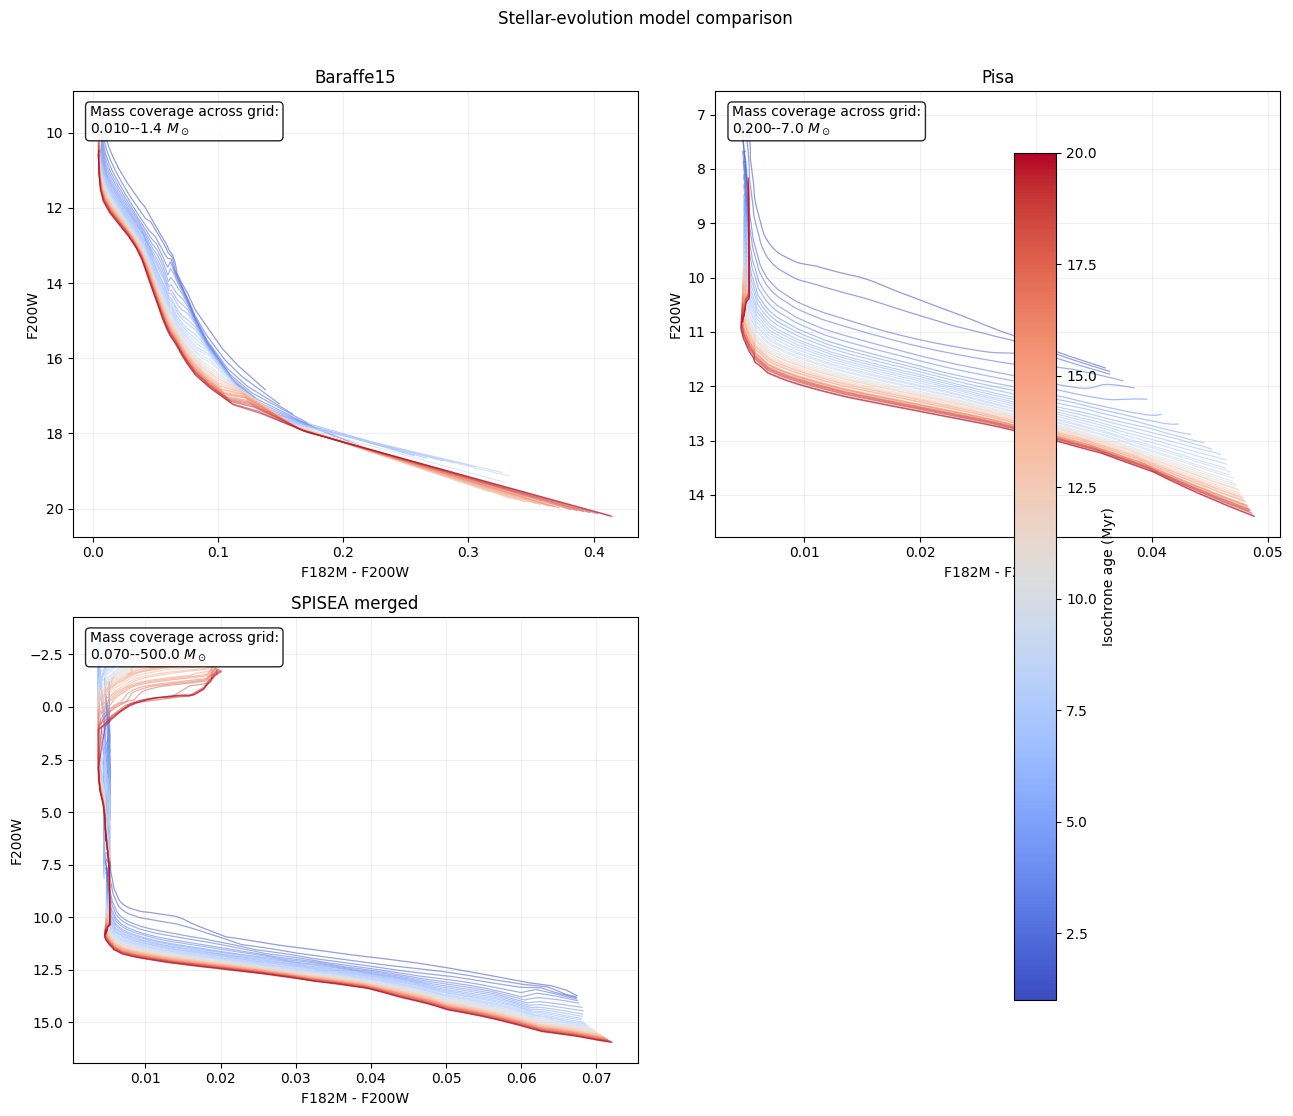

In [14]:
plot_model_isochrone_grids(MODEL_GRIDS)

In [15]:
def safe_interpolate(
    age_myr,
    mass,
    iso_grid,
    log_age_arr,
    filters=FILTER_KEYS,
):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')

            with contextlib.redirect_stdout(io.StringIO()):
                with contextlib.redirect_stderr(io.StringIO()):
                    return interpolator.interpolate(
                        age_myr,
                        mass,
                        iso_grid,
                        log_age_arr,
                        filters,
                    )

    except Exception:
        return None

In [16]:
def combine_magnitudes(magnitudes):
    magnitudes = np.asarray(
        magnitudes,
        dtype=float
    )
    magnitudes = magnitudes[
        np.isfinite(magnitudes)
    ]

    if len(magnitudes) == 0:
        return np.nan

    relative_flux = np.sum(
        10.0 ** (-0.4 * magnitudes)
    )

    return -2.5 * np.log10(relative_flux)

In [17]:
def interpolate_snapshot_for_model(
    cluster_table,
    iso_grid,
    log_age_arr=LOG_AGES,
):
    resolved_rows = []
    unresolved_rows = []
    rejection_rows = []

    for system_index, row in enumerate(cluster_table):
        primary_mass = float(row['mass'])
        age_myr = float(row['age'])
        is_multiple = bool(row['isMultiple'])

        primary = safe_interpolate(
            age_myr,
            primary_mass,
            iso_grid,
            log_age_arr,
        )

        if primary is None:
            rejection_rows.append({
                'system_index': system_index,
                'component': 'primary',
                'mass': primary_mass,
                'reason': 'outside interpolation coverage',
            })
            continue

        primary_mag1 = float(primary[3])
        primary_mag2 = float(primary[4])

        resolved_rows.append({
            'system_index': system_index,
            'component': 'primary',
            'mass': primary_mass,
            'age_myr': age_myr,
            'mag1': primary_mag1,
            'mag2': primary_mag2,
            'color': primary_mag1 - primary_mag2,
            'ymag': primary_mag2,
        })

        companion_results = []
        companions_valid = True

        companion_masses = (
            list(row['compMass'])
            if is_multiple else []
        )

        for companion_number, companion_mass in enumerate(
            companion_masses,
            start=1,
        ):
            companion_mass = float(companion_mass)

            companion = safe_interpolate(
                age_myr,
                companion_mass,
                iso_grid,
                log_age_arr,
            )

            if companion is None:
                companions_valid = False

                rejection_rows.append({
                    'system_index': system_index,
                    'component':
                        f'companion_{companion_number}',
                    'mass': companion_mass,
                    'reason':
                        'outside interpolation coverage',
                })
                continue

            companion_mag1 = float(companion[3])
            companion_mag2 = float(companion[4])

            companion_results.append({
                'mass': companion_mass,
                'mag1': companion_mag1,
                'mag2': companion_mag2,
            })

            resolved_rows.append({
                'system_index': system_index,
                'component':
                    f'companion_{companion_number}',
                'mass': companion_mass,
                'age_myr': age_myr,
                'mag1': companion_mag1,
                'mag2': companion_mag2,
                'color':
                    companion_mag1 - companion_mag2,
                'ymag': companion_mag2,
            })

        if not is_multiple:
            unresolved_rows.append({
                'system_index': system_index,
                'is_multiple': False,
                'primary_mass': primary_mass,
                'system_mass': primary_mass,
                'age_myr': age_myr,
                'mag1': primary_mag1,
                'mag2': primary_mag2,
                'color':
                    primary_mag1 - primary_mag2,
                'ymag': primary_mag2,
            })

        elif companions_valid:
            combined_mag1 = combine_magnitudes(
                [primary_mag1]
                + [c['mag1']
                   for c in companion_results]
            )
            combined_mag2 = combine_magnitudes(
                [primary_mag2]
                + [c['mag2']
                   for c in companion_results]
            )

            unresolved_rows.append({
                'system_index': system_index,
                'is_multiple': True,
                'primary_mass': primary_mass,
                'system_mass':
                    primary_mass
                    + sum(c['mass']
                          for c in companion_results),
                'age_myr': age_myr,
                'mag1': combined_mag1,
                'mag2': combined_mag2,
                'color':
                    combined_mag1 - combined_mag2,
                'ymag': combined_mag2,
            })

    return {
        'resolved':
            pd.DataFrame(resolved_rows),
        'unresolved':
            pd.DataFrame(unresolved_rows),
        'rejected':
            pd.DataFrame(rejection_rows),
    }

In [18]:
MODEL_CATALOGS = {}

for model_name, iso_grid in MODEL_GRIDS.items():
    print(f'Interpolating {model_name}')

    MODEL_CATALOGS[model_name] = (
        interpolate_snapshot_for_model(
            cluster_table,
            iso_grid,
        )
    )

Interpolating Baraffe15
Interpolating Pisa
Interpolating SPISEA merged


In [19]:
def summarize_model_retention(
    cluster_table,
    model_catalogs,
):
    n_systems_total = len(cluster_table)

    n_binary_total = int(
        np.sum(
            np.asarray(
                cluster_table['isMultiple'],
                dtype=float
            ) == 1.0
        )
    )

    rows = []

    for model_name, catalogs in model_catalogs.items():
        unresolved = catalogs['unresolved']
        rejected = catalogs['rejected']

        modeled_systems = (
            unresolved['system_index'].nunique()
            if len(unresolved) else 0
        )

        modeled_binary_systems = (
            unresolved.loc[
                unresolved['is_multiple'],
                'system_index'
            ].nunique()
            if len(unresolved) else 0
        )

        companion_rejections = (
            np.sum(
                rejected['component']
                .astype(str)
                .str.startswith('companion')
            )
            if len(rejected) else 0
        )

        rows.append({
            'model': model_name,
            'systems_total': n_systems_total,
            'systems_retained': modeled_systems,
            'system_retention_fraction':
                modeled_systems / n_systems_total,
            'binary_systems_total': n_binary_total,
            'binary_systems_retained':
                modeled_binary_systems,
            'binary_retention_fraction':
                modeled_binary_systems
                / n_binary_total
                if n_binary_total else np.nan,
            'rejected_companions':
                companion_rejections,
        })

    return pd.DataFrame(rows)

In [20]:
df_retention = summarize_model_retention(
    cluster_table,
    MODEL_CATALOGS,
)

df_retention

,model,systems_total,systems_retained,system_retention_fraction,binary_systems_total,binary_systems_retained,binary_retention_fraction,rejected_companions
0,Baraffe15,756,320,0.423280,363,142,0.391185,0
1,Pisa,756,99,0.130952,363,27,0.074380,21
2,SPISEA merged,756,209,0.276455,363,71,0.195592,30


In [21]:
def plot_model_binary_comparison(
    model_catalogs,
):
    n_models = len(model_catalogs)

    fig, axes = plt.subplots(
        n_models,
        2,
        figsize=(12, 5 * n_models),
        squeeze=False,
    )

    for row_idx, (
        model_name,
        catalogs,
    ) in enumerate(model_catalogs.items()):

        resolved = catalogs['resolved']
        unresolved = catalogs['unresolved']

        ax = axes[row_idx, 0]

        if len(resolved):
            ax.scatter(
                resolved['color'],
                resolved['ymag'],
                s=5,
                alpha=0.45,
            )

        ax.set_title(
            f'{model_name}: resolved components\n'
            f'N={len(resolved)} sources'
        )
        ax.set_xlabel(COLOR_LABEL)
        ax.set_ylabel(MAG_LABEL)
        ax.invert_yaxis()
        ax.grid(alpha=0.2)

        ax = axes[row_idx, 1]

        if len(unresolved):
            singles = unresolved[
                ~unresolved['is_multiple']
            ]
            binaries = unresolved[
                unresolved['is_multiple']
            ]

            ax.scatter(
                singles['color'],
                singles['ymag'],
                s=5,
                alpha=0.4,
                label='single systems',
            )
            ax.scatter(
                binaries['color'],
                binaries['ymag'],
                s=8,
                alpha=0.6,
                label='unresolved multiples',
            )

        retained = (
            unresolved['system_index'].nunique()
            if len(unresolved) else 0
        )

        ax.set_title(
            f'{model_name}: unresolved systems\n'
            f'N={retained} retained systems'
        )
        ax.set_xlabel(COLOR_LABEL)
        ax.set_ylabel(MAG_LABEL)
        ax.invert_yaxis()
        ax.grid(alpha=0.2)
        ax.legend()

    plt.tight_layout()
    plt.show()

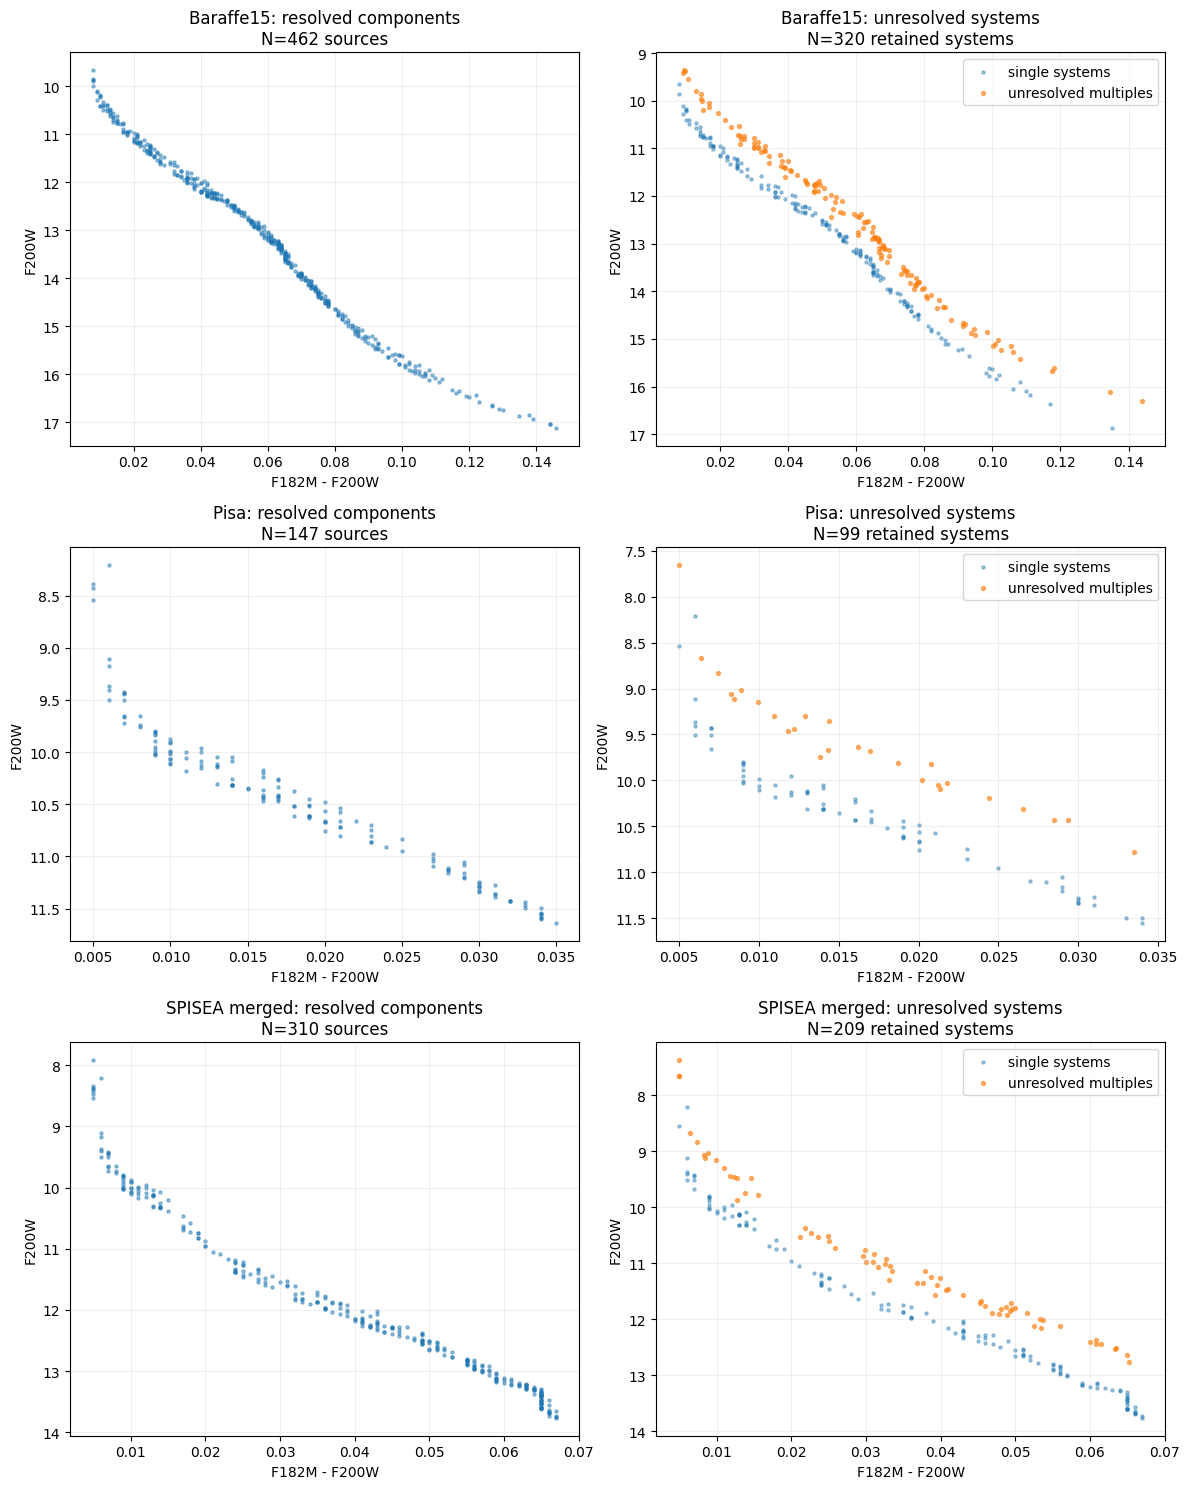

In [22]:
plot_model_binary_comparison(MODEL_CATALOGS)

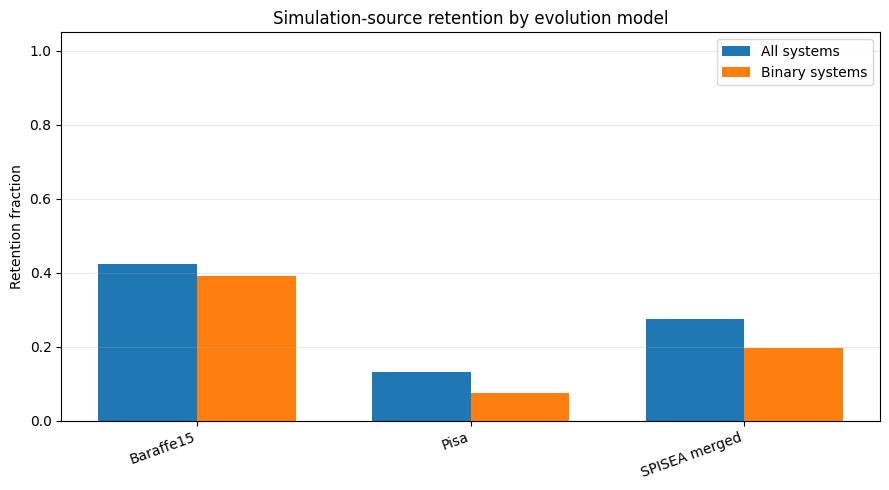

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(df_retention))
width = 0.36

ax.bar(
    x - width / 2,
    df_retention['system_retention_fraction'],
    width,
    label='All systems',
)

ax.bar(
    x + width / 2,
    df_retention['binary_retention_fraction'],
    width,
    label='Binary systems',
)

ax.set_xticks(x)
ax.set_xticklabels(
    df_retention['model'],
    rotation=20,
    ha='right',
)
ax.set_ylabel('Retention fraction')
ax.set_ylim(0, 1.05)
ax.set_title(
    'Simulation-source retention by evolution model'
)
ax.grid(axis='y', alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()